Graph: 548 nodes, 1100 edges
Fraud nodes: 48 (8.8%)

Extracting features (this takes ~20s for betweenness)...
      degree  clustering_coef  pagerank  betweenness  closeness  triangles  \
node                                                                         
0         66         0.009790  0.025487     0.267105   0.393808         21   
1         58         0.017544  0.022686     0.309904   0.400146         29   
2         13         0.051282  0.005141     0.019892   0.330913          4   
3         10         0.044444  0.004276     0.021248   0.321954          2   
4         51         0.013333  0.019974     0.209865   0.383053         17   

      neighbor_fraud_frac  neighbor_degree_mean  neighbor_degree_max  \
node                                                                   
0                     0.0              6.000000                   58   
1                     0.0              7.551724                   66   
2                     0.0             13.615385        

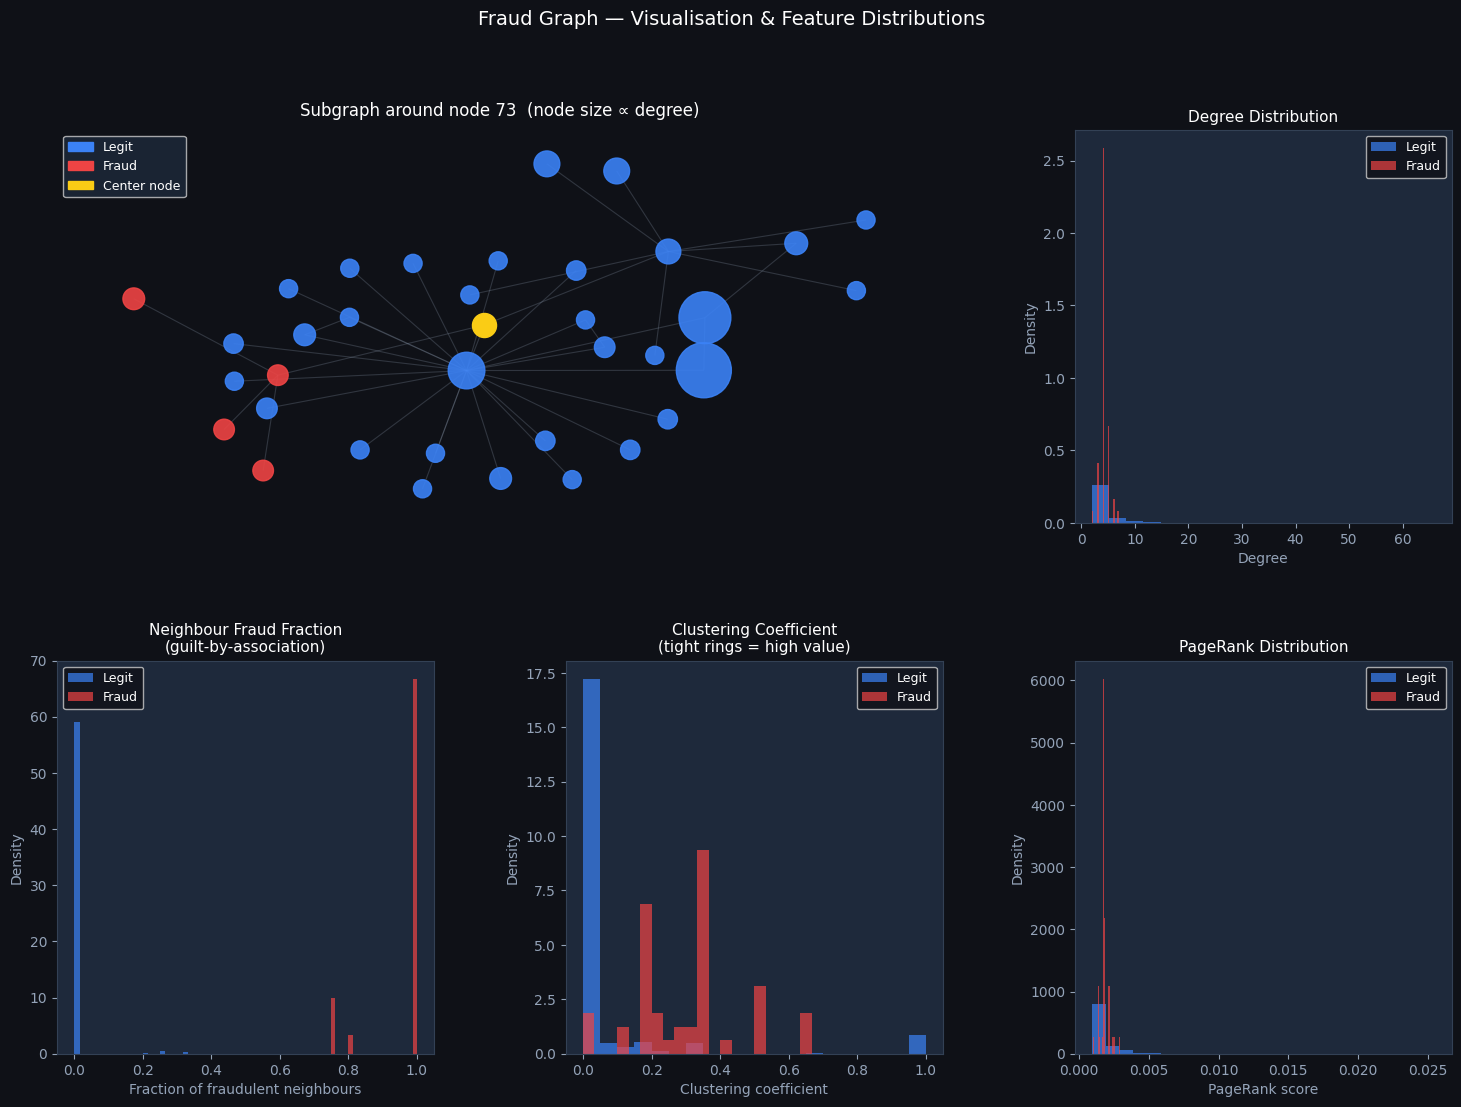

In [1]:
"""
Fraud Graph: Visualization + Feature Extraction
================================================
Generates a synthetic fraud graph, visualizes a subset,
and computes node-level features ready for logistic regression.

Swap out the graph-building section with your real data
(Elliptic, FraudAmazon, etc.) and the rest works unchanged.

The visualisation (5 panels)
----------------------------
Top-left — subgraph around a "bridge" node connecting the legit network to a fraud ring. Node size = degree, red = fraud, blue = legit. You can see fraud nodes clustering tightly together.
Top-right — degree distribution: fraud nodes tend to have more uniform, moderate degrees (ring topology), legit nodes have a heavy-tailed scale-free distribution.
Bottom row — feature distributions split by class, showing how each feature separates fraud from legit.


What the coefficients tell you
------------------------------
The most predictive features (from the logistic regression run):
Feature                    Effect     Why   
neighbor_fraud_frac        +2.28      Strongest signal — guilt by association
neighbor_clustering        +0.72      Fraud rings have densely connected neighbours
clustering_coef            +0.15      Fraud nodes sit in tight triangles
closeness                  -0.80      Fraud rings are peripheral, far from network core

To swap in real data
--------------------
Just replace the graph-building block at the top with your own G = nx.Graph(...) loaded from Elliptic edges or DGL, set the "fraud" node attribute, and the feature extraction + plotting runs unchanged.
"""

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ── 1. BUILD SYNTHETIC FRAUD GRAPH ───────────────────────────────────────────
# Structure:
#   • ~500 legit nodes — loosely connected (Barabasi-Albert)
#   • ~50  fraud nodes — tightly clustered rings (Watts-Strogatz style)
#   • A few edges connecting fraud ring to legit network (bridge nodes)

N_LEGIT = 500
N_FRAUD = 50

# Legit subgraph (scale-free — realistic for transaction networks)
G_legit = nx.barabasi_albert_graph(N_LEGIT, m=2, seed=42)

# Fraud rings: 3 small tightly-knit communities
fraud_rings = []
for i in range(3):
    ring = nx.watts_strogatz_graph(16, k=4, p=0.3, seed=i)
    fraud_rings.append(ring)

# Combine into one graph
G = nx.Graph()
G.add_nodes_from(G_legit.nodes(data=True))
G.add_edges_from(G_legit.edges())

fraud_node_ids = []
offset = N_LEGIT
for ring in fraud_rings:
    mapping = {n: n + offset for n in ring.nodes()}
    G.add_nodes_from(mapping.values())
    G.add_edges_from((mapping[u], mapping[v]) for u, v in ring.edges())
    fraud_node_ids.extend(mapping.values())
    offset += ring.number_of_nodes()

# Bridge edges: fraud rings connect to a few legit nodes
bridge_legit = np.random.choice(N_LEGIT, size=8, replace=False)
bridge_fraud  = np.random.choice(fraud_node_ids, size=8, replace=False)
for l, f in zip(bridge_legit, bridge_fraud):
    G.add_edge(l, f)

# Assign labels
labels = {n: 0 for n in G.nodes()}
for n in fraud_node_ids:
    labels[n] = 1
nx.set_node_attributes(G, labels, "fraud")

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Fraud nodes: {sum(labels.values())} ({100*sum(labels.values())/G.number_of_nodes():.1f}%)")


# ── 2. FEATURE EXTRACTION ────────────────────────────────────────────────────

def extract_features(G):
    """Compute interpretable node-level features from graph structure."""
    nodes = list(G.nodes())

    # — Structural —
    degree          = dict(G.degree())
    clustering      = nx.clustering(G)
    pagerank        = nx.pagerank(G, alpha=0.85)
    # Betweenness is expensive; sample for large graphs
    betweenness     = nx.betweenness_centrality(G, k=min(100, len(nodes)))
    closeness       = nx.closeness_centrality(G)

    # — Neighborhood / guilt-by-association —
    fraud_label     = nx.get_node_attributes(G, "fraud")

    neighbor_fraud_frac  = {}
    neighbor_degree_mean = {}
    neighbor_degree_max  = {}
    neighbor_clustering  = {}

    for n in nodes:
        nbrs = list(G.neighbors(n))
        if nbrs:
            neighbor_fraud_frac[n]  = np.mean([fraud_label.get(nb, 0) for nb in nbrs])
            nbr_degrees             = [degree[nb] for nb in nbrs]
            neighbor_degree_mean[n] = np.mean(nbr_degrees)
            neighbor_degree_max[n]  = np.max(nbr_degrees)
            neighbor_clustering[n]  = np.mean([clustering[nb] for nb in nbrs])
        else:
            neighbor_fraud_frac[n]  = 0.0
            neighbor_degree_mean[n] = 0.0
            neighbor_degree_max[n]  = 0.0
            neighbor_clustering[n]  = 0.0

    # — Ego-graph features —
    triangle_count = {n: sum(nx.triangles(G, n) for n in [n]) for n in nodes}
    # (nx.triangles returns per-node count directly)
    triangles = nx.triangles(G)

    rows = []
    for n in nodes:
        rows.append({
            "node":                  n,
            "degree":                degree[n],
            "clustering_coef":       clustering[n],
            "pagerank":              pagerank[n],
            "betweenness":           betweenness[n],
            "closeness":             closeness[n],
            "triangles":             triangles[n],
            "neighbor_fraud_frac":   neighbor_fraud_frac[n],
            "neighbor_degree_mean":  neighbor_degree_mean[n],
            "neighbor_degree_max":   neighbor_degree_max[n],
            "neighbor_clustering":   neighbor_clustering[n],
            "label":                 fraud_label.get(n, 0),
        })

    return pd.DataFrame(rows).set_index("node")

print("\nExtracting features (this takes ~20s for betweenness)...")
df = extract_features(G)
print(df.head())
print(f"\nFeature matrix shape: {df.shape}")


# ── 3. VISUALISATION ─────────────────────────────────────────────────────────

def plot_subgraph(G, df, center_node=None, radius=2, max_nodes=120):
    """
    Extract a neighbourhood subgraph and plot it with fraud labels coloured.
    If center_node is None, picks a bridge node (connected to both classes).
    """
    # Pick a bridge node as center for an interesting view
    if center_node is None:
        for n in G.nodes():
            nbrs = list(G.neighbors(n))
            if len(nbrs) >= 3:
                fraud_nbrs = sum(df.loc[nb, "label"] for nb in nbrs if nb in df.index)
                if fraud_nbrs >= 1 and (len(nbrs) - fraud_nbrs) >= 1:
                    center_node = n
                    break

    # BFS to radius
    sub_nodes = set()
    frontier  = {center_node}
    for _ in range(radius):
        next_frontier = set()
        for n in frontier:
            next_frontier.update(G.neighbors(n))
        sub_nodes.update(frontier)
        frontier = next_frontier - sub_nodes
        if len(sub_nodes) > max_nodes:
            break
    sub_nodes.update(list(frontier)[:max(0, max_nodes - len(sub_nodes))])
    sub_nodes = list(sub_nodes)[:max_nodes]

    H = G.subgraph(sub_nodes)
    return H, center_node


fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0f1117")
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# ── Panel 1: Subgraph around a bridge node ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor("#0f1117")

H, center = plot_subgraph(G, df)
pos = nx.spring_layout(H, seed=42, k=0.6)

node_colors = ["#ef4444" if df.loc[n, "label"] == 1 else "#3b82f6"
               for n in H.nodes()]
node_sizes  = [120 + df.loc[n, "degree"] * 25 for n in H.nodes()]
edge_alpha  = [0.6 if (df.loc[u, "label"] == 1 or df.loc[v, "label"] == 1) else 0.2
               for u, v in H.edges()]

nx.draw_networkx_edges(H, pos, ax=ax1, alpha=0.25, edge_color="#94a3b8", width=0.8)
nx.draw_networkx_nodes(H, pos, ax=ax1,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.9)
# Highlight center
nx.draw_networkx_nodes(H, pos, nodelist=[center], ax=ax1,
                       node_color="#facc15", node_size=300, alpha=1.0)

fraud_patch  = mpatches.Patch(color="#ef4444", label="Fraud")
legit_patch  = mpatches.Patch(color="#3b82f6", label="Legit")
center_patch = mpatches.Patch(color="#facc15", label="Center node")
ax1.legend(handles=[legit_patch, fraud_patch, center_patch],
           facecolor="#1e293b", labelcolor="white", fontsize=9, loc="upper left")
ax1.set_title(f"Subgraph around node {center}  (node size ∝ degree)",
              color="white", fontsize=12, pad=10)
ax1.axis("off")

# ── Panel 2: Degree distribution ──
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor("#1e293b")

for label, color, name in [(0, "#3b82f6", "Legit"), (1, "#ef4444", "Fraud")]:
    subset = df[df["label"] == label]["degree"]
    ax2.hist(subset, bins=20, alpha=0.7, color=color, label=name, density=True)

ax2.set_title("Degree Distribution", color="white", fontsize=11)
ax2.set_xlabel("Degree", color="#94a3b8")
ax2.set_ylabel("Density", color="#94a3b8")
ax2.tick_params(colors="#94a3b8")
ax2.legend(facecolor="#0f1117", labelcolor="white", fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor("#334155")

# ── Panel 3: Neighbour fraud fraction ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor("#1e293b")

for label, color, name in [(0, "#3b82f6", "Legit"), (1, "#ef4444", "Fraud")]:
    subset = df[df["label"] == label]["neighbor_fraud_frac"]
    ax3.hist(subset, bins=20, alpha=0.7, color=color, label=name, density=True)

ax3.set_title("Neighbour Fraud Fraction\n(guilt-by-association)", color="white", fontsize=11)
ax3.set_xlabel("Fraction of fraudulent neighbours", color="#94a3b8")
ax3.set_ylabel("Density", color="#94a3b8")
ax3.tick_params(colors="#94a3b8")
ax3.legend(facecolor="#0f1117", labelcolor="white", fontsize=9)
for spine in ax3.spines.values():
    spine.set_edgecolor("#334155")

# ── Panel 4: Clustering coefficient ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor("#1e293b")

for label, color, name in [(0, "#3b82f6", "Legit"), (1, "#ef4444", "Fraud")]:
    subset = df[df["label"] == label]["clustering_coef"]
    ax4.hist(subset, bins=20, alpha=0.7, color=color, label=name, density=True)

ax4.set_title("Clustering Coefficient\n(tight rings = high value)", color="white", fontsize=11)
ax4.set_xlabel("Clustering coefficient", color="#94a3b8")
ax4.set_ylabel("Density", color="#94a3b8")
ax4.tick_params(colors="#94a3b8")
ax4.legend(facecolor="#0f1117", labelcolor="white", fontsize=9)
for spine in ax4.spines.values():
    spine.set_edgecolor("#334155")

# ── Panel 5: PageRank ──
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor("#1e293b")

for label, color, name in [(0, "#3b82f6", "Legit"), (1, "#ef4444", "Fraud")]:
    subset = df[df["label"] == label]["pagerank"]
    ax5.hist(subset, bins=25, alpha=0.7, color=color, label=name, density=True)

ax5.set_title("PageRank Distribution", color="white", fontsize=11)
ax5.set_xlabel("PageRank score", color="#94a3b8")
ax5.set_ylabel("Density", color="#94a3b8")
ax5.tick_params(colors="#94a3b8")
ax5.legend(facecolor="#0f1117", labelcolor="white", fontsize=9)
for spine in ax5.spines.values():
    spine.set_edgecolor("#334155")

fig.suptitle("Fraud Graph — Visualisation & Feature Distributions",
             color="white", fontsize=14, y=0.98)

plt.savefig("./fraud_graph.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("\nPlot saved.")


# ── 4. QUICK LOGISTIC REGRESSION ─────────────────────────────────────────────

feature_cols = [c for c in df.columns if c != "label"]
X = df[feature_cols].values
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(class_weight="balanced", C=0.5, max_iter=1000)
clf.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": clf.coef_[0],
}).sort_values("coefficient", ascending=False)

print("\n── Logistic Regression Coefficients ──")
print(coef_df.to_string(index=False))
print("\n── Classification Report (train set) ──")
print(classification_report(y, clf.predict(X_scaled), target_names=["Legit", "Fraud"]))